In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path

import pandas as pd
import numpy as np

from utils import DATA_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

In [3]:
pull_predictions_from_weka("aws")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_aws_predictions.parquet


In [4]:
df = pd.read_parquet(f'{DATA_DIR}/all_aws_predictions.parquet')

In [5]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
STEPS  = df.index.get_level_values('step').unique().to_list()

TASKS = [t for t in TASKS if 'mmlu' not in t]
TASKS = sorted(TASKS)

print(MODELS)
print(TASKS)
print(MIXES)
# print(STEPS)

['peteish-moreeval-190M-2xC', 'peteish-moreeval-rerun-370M-1xC', 'peteish-moreeval-190M-0.5xC', 'peteish-moreeval-370M-0.5xC', 'peteish-moreeval-1B-0.5xC', 'peteish-moreeval-760M-2xC', 'peteish-moreeval-1B-2xC', 'peteish-moreeval-rerun-760M-1xC', 'peteish-moreeval-370M-2xC', 'peteish-moreeval-1B-5xC', 'peteish-moreeval-rerun-190M-1xC', 'peteish-moreeval-3B-0.5xC', 'peteish-moreeval-760M-0.5xC', 'peteish-moreeval-rerun-1B-1xC', 'OLMo-1B-hf', 'OLMo-7B-0724-hf', 'DCLM-baseline-1B-5xC', 'no_code-1B-5xC', 'no_reddit-1B-5xC', 'peteish-moreeval-370M-10xC', 'falcon-1B-5xC', 'peteish-moreeval-3B-5xC', 'peteish-moreeval-1B-10xC', 'no_math_no_code-1B-5xC', 'c4-1B-5xC', 'redpajama-1B-5xC', 'peteish13-highlr', 'peteish7', 'phi-1_5', 'dolma17-75p-DCLM-baseline-25p-1B-5xC', 'peteish-moreeval-760M-10xC', 'peteish-moreeval-3B-10xC', 'peteish-moreeval-rerun-3B-1xC', 'peteish-moreeval-3B-2xC', 'peteish-moreeval-190M-5xC', 'peteish-moreeval-760M-5xC', 'peteish-moreeval-370M-5xC', 'peteish-moreeval-190M-10

In [6]:
# models, scores = get_nd_array(df, 'model', 'acc_per_char', task='arc_challenge:distractors')
# models, scores = get_nd_array(df, ['model', 'mix'], 'acc_per_char', task='arc_challenge:distractors')

### Measure 1: Predictability (Rel Error @ 7B)

In [7]:
# https://arxiv.org/pdf/2412.04403#page=3.57
LADDER_MODELS = [model for model in MODELS if 'peteish-moreeval' in model]

/Users/dhei/miniconda3/envs/metaeval/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


-0.06003510757433322


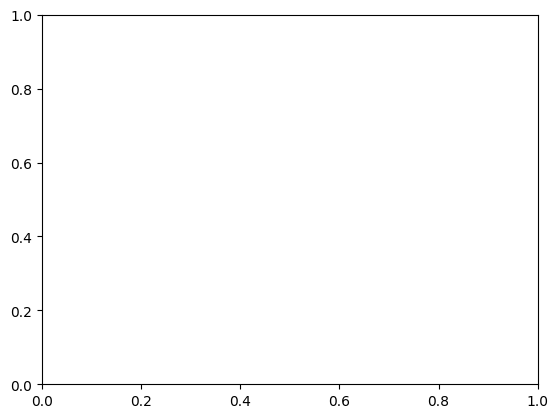

In [8]:
from olmo.scaling.scaling_laws.utils import get_final_configs, get_step2_data_by_name, get_task_sets
from scaling.step2 import main as step2_main
from scaling.step2 import fit_step2, predict_step2, plot_step2

os.chdir('/Users/dhei/ai2/new-evals/olmo-repos/OLMo')

config_path = "scripts/scaling/final.json"
# config_path = "scripts/scaling/final_7b_only.json"

configs = get_final_configs(config_path)
task_names = get_task_sets(["v2_main_variance"])

data_by_name = get_step2_data_by_name(
    configs,
    'arc_easy_test_5shot',
    x_metric='rc_bpb',
    y_metric='rc_acc',
    moving_avg=5,
    skip_perc=0.1,
)

coefficients, cov = fit_step2(data_by_name, 'arc_easy_test_5shot', 'rc_acc', use_log_sigmoid=False)

(
    predicted_data_by_name, plotted_predicted_data,
    (y, y_pred, rel_error, delta_error), all_rel_errors,
) = predict_step2(
    configs, data_by_name, coefficients, cov, y_metric='rc_acc', use_log_sigmoid=False
)

print(rel_error)

In [9]:
# labeled by size
data_by_name['1B'].keys()

# xs - task loss
# ys - task accuracy
# ds - tokens (step 1) -- can take from wandb logs processed by olmo script (for Ian's project I'd can hook up the same script to extract wandb info)
from olmo.scaling.scaling_laws.utils import MODEL_FLOPS, FinalConfig
# ns - params (step 1) -- can extract from config file
# ls - labels (step 1)
# mode - train/eval

In [10]:
from download.preprocess import SIZE_PREFIXES, str_find
from collections import defaultdict

def get_ladder_data(df, task_name, train_models, eval_models):
    """ Get slices of df and convert to ladder prediction format """
    data_by_name = defaultdict(dict)

    for model in train_models + eval_models:
        # Use ladder models only
        if model in eval_models:
            mode = 'eval'
            if model == 'peteish7':
                size = '7B-4T'
            elif 'peteish13-highlr' in model:
                size = '13B-5T'
            else:
                size = model
        elif model in train_models:
            mode = 'train'
            size = str_find(SIZE_PREFIXES, model)
            if size is not None and size != '-3B-': 
                size = size.replace('-', '')
            else:
                size = model
        else:
            raise NameError(model)

        m1, corr = get_nd_array(df, 'model', 'correct_choice', model=model, task=task_name, step='max')
        m2, bpb  = get_nd_array(df, 'model', 'logits_per_byte', model=model, task=task_name, step='max')
        m3, acc  = get_nd_array(df, 'model', 'acc_per_char', model=model, task=task_name, step='max')

        # Ensure the model results are all the same model names
        # assert [_1 == _2 == _3 for _1, _2, _3 in zip(m1, m2, m3)], f'{model} failed'
        if not all(_1 == _2 == _3 for _1, _2, _3 in zip(m1, m2, m3)):
            print(f"{model} failed")
            continue

        # if mode == 'eval': 
        #     print(corr)
        #     print(acc)
        #     print(size)

        if len(corr) == 0 or len(bpb) == 0 or len(acc) == 0: 
            # if mode == 'eval':
            #     raise RuntimeError(f'Eval point data not found: {model}')
            continue
        
        # print(acc.shape, acc.mean(axis=1), model)

        # Get correct logprobs per char
        n_choices = bpb[0][0].shape
        correct_bpb = np.empty_like(corr, dtype=np.float64)
        rows, cols = corr.shape
        for i in range(rows):
            for j in range(cols):
                if corr[i, j] == n_choices and 'enlarge' in task_name: 
                    # print(f'Warning: bpb has {n_choices} choices, but the correct label is {corr[i, j]} (did ChatGPT generate an incorrect ground truth?). re-indexing the correct label...')
                    corr[i, j] -= 1
                correct_bpb[i, j] = bpb[i, j][corr[i, j]]

        acc = acc.mean(axis=1)
        correct_bpb = correct_bpb.mean(axis=1)

        if 'xs' not in data_by_name[size]: data_by_name[size]['xs'] = []
        if 'ys' not in data_by_name[size]: data_by_name[size]['ys'] = []

        data_by_name[size]['xs'] += [correct_bpb.item()]
        data_by_name[size]['ys'] += [acc.item()]
        data_by_name[size]['mode'] = mode

    return data_by_name

task_name = 'arc_challenge'
data_by_name = get_ladder_data(df, task_name, LADDER_MODELS, ['peteish7'])

In [11]:
# Sanity check: enlarge results
task_name = 'arc_easy:enlarge'
model = 'peteish7'
m2, bpb  = get_nd_array(df, 'model', 'logits_per_byte', model=model, task=task_name, step='max')
data_by_name = get_ladder_data(df, task_name, LADDER_MODELS, ['peteish_7'])

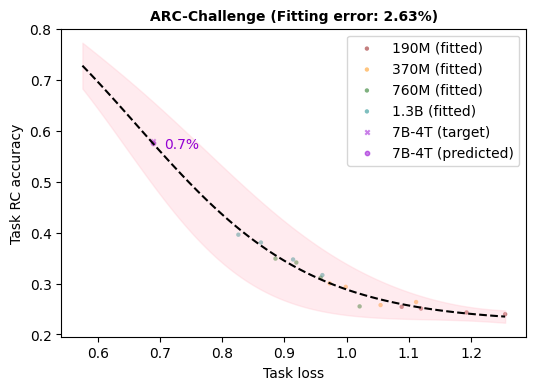

In [12]:
import matplotlib.pyplot as plt

TASK_KEY_MAP = {
    "arc_challenge": "arc_challenge_test_5shot",
    "arc_easy": "arc_easy_test_5shot",
    "boolq": "boolq_val_5shot",
    "socialiqa": "socialiqa_val_5shot",
    "csqa": "csqa_val_5shot",
    "hellaswag": "hellaswag_val_5shot",
    "openbookqa": "openbookqa_test_5shot",
    "winogrande": "winogrande_val_5shot",
    "piqa": "piqa_val_5shot",
}

akshita_ladder_models = [model for model in LADDER_MODELS if '3B' not in model and '0.5xC' not in model]

def run_ladder(df, task_name, train_models=akshita_ladder_models, eval_models=['peteish7'], ax=None):
    task_root = task_name.split(':')[0] # arc_easy:enlarge => arc_easy

    data_by_name = get_ladder_data(df, task_name, train_models, eval_models)

    # Manual override for configs
    for model in eval_models:
        if model not in akshita_ladder_models:
            # configs[model] = {
            #     'mode': 'train', 'n': 0, 'label': model,
            #     'color': 'red', 'use_last_n_percentage': 100
            # }
            color = 'red'
            if 'Qwen' in model: color = 'green'
            elif 'Llama' in model or 'LLaMA' in model: color = 'blue'
            elif 'Mistral' in model: color = 'orange'
            elif '3B' in model: color = 'black'
            elif 'OLMo' in model: color = 'yellow'
            elif 'pythia' in model: color = 'brown'
            elif 'gemma' in model: color = 'teal'
            elif 'phi' in model: color = 'black'
            elif 'deepseek' in model: color = 'pink'
            elif 'zephyr' in model: color = 'green'
            elif 'neo' in model: color = 'orange'
            elif 'falcon' in model: color = 'blue'
            configs[model] = FinalConfig(
                paths=None, mode='eval', n=0, label=model, color=color, use_last_n_percentage=100
            )

    task_key = TASK_KEY_MAP[task_root] # the task key is used to get min/max perf and plot title

    try:
        coefficients, cov = fit_step2(data_by_name, task_key, None, use_log_sigmoid=False)
    except Exception as e:
        print(data_by_name)
        raise RuntimeError(f'Failed to fit: {e}')

    (
        predicted_data_by_name, plotted_predicted_data,
        (y, y_pred, rel_error, delta_error), all_rel_errors,
    ) = predict_step2(
        configs, data_by_name, coefficients, cov, y_metric='rc_acc', use_log_sigmoid=False
    )

    plot_step2(
        configs, data_by_name, predicted_data_by_name, plotted_predicted_data, task_key, None, 'rc_bpb', 'rc_acc',
        coefficients, cov, use_log_sigmoid=False, ax=ax
    )

    return y, y_pred, rel_error, delta_error

# python scripts/scaling/step2.py -k v2_main -c scripts/scaling/step2.json -o figure/peteish-moreeval/step2_main.pdf --skip_perc 1
fig, axes = plt.subplots(1, 1, figsize=(6, 4), squeeze=False)
y, y_pred, rel_error, delta_error = run_ladder(df, 'arc_challenge', ax=axes[0][0])

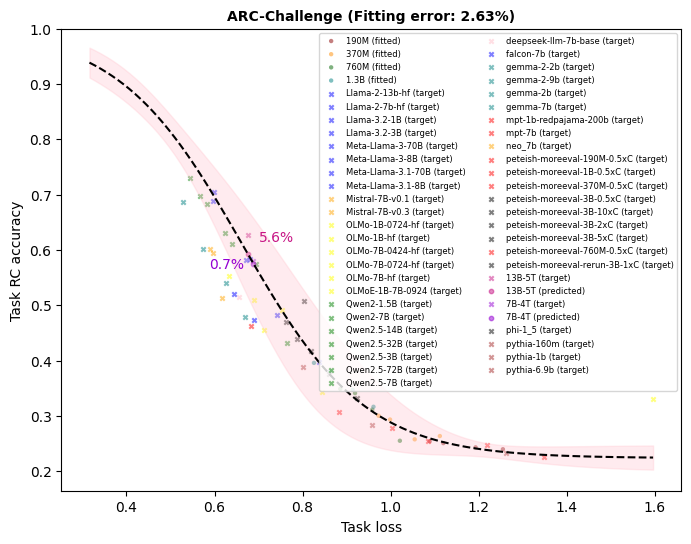

In [13]:
from utils.constants_models import MODEL_LIST_MIXES
MODEL_LIST_MIXES = [model.split('/')[-1] for model in MODEL_LIST_MIXES]
# BROKEN_MODELS = [
#     'gemma-7b', 'gemma-2-9b', 'Qwen2.5-32B', 'OLMo-7B-0424-hf', 'Meta-Llama-3.1-70B', 
#     'Llama-2-13b-hf', 'peteish13-highlr', 'Llama-2-13b-hf', 'zephyr-7b-beta'
# ]
BROKEN_MODELS = []
all_models = sorted([model for model in MODELS if model not in MODEL_LIST_MIXES + BROKEN_MODELS + akshita_ladder_models])

fig, axes = plt.subplots(1, 1, figsize=(8, 6), squeeze=False)
y, y_pred, rel_error, delta_error = run_ladder(df, 'arc_challenge', eval_models=all_models, ax=axes[0][0])
_ = axes[0][0].legend(fontsize=6, ncol=2)

In [14]:
num_rows, num_cols = len(TASKS), 1
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 4 * num_rows), squeeze=False)

fitting_results = pd.DataFrame(index=['rel_error'], columns=TASKS)

for i, task in enumerate(TASKS):
    ax = axes[i, 0]

    try:
        # y, y_pred, rel_error, delta_error = run_ladder(df, task, eval_models=all_models, ax=ax)
        y, y_pred, rel_error, delta_error = run_ladder(df, task, ax=ax)

        ax.set_title(task)
        ax.legend(fontsize=4, ncol=2)

        fitting_results.loc['rel_error', task] = abs(rel_error)
    except Exception as e:
        print(f'{task} failed: {e}')
        continue

fig.tight_layout()

plt.close(fig)

In [15]:
from table import display_task_variants

print(f'Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:')
display_task_variants(fitting_results, key='rel_error', inverse=True, ascending=True)

Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_challenge,0.7%,0.6% (-0.1%),7.0% (+6.3%),14.9% (+14.3%)
piqa,0.8%,--,--,1.9% (+1.2%)
hellaswag,0.9%,--,--,2.3% (+1.4%)
arc_easy,2.9%,0.7% (-2.2%),6.5% (+3.6%),2.8% (-0.1%)
csqa,4.8%,--,--,2.5% (-2.2%)
socialiqa,5.4%,--,--,3.9% (-1.4%)
openbookqa,8.0%,--,--,13.8% (+5.7%)
boolq,14.0%,--,--,2.3% (-11.7%)
winogrande,14.8%,--,--,13.3% (-1.5%)


In [16]:
# TODO:
    # Implement step 1 / stacked prediction
    # Add C4 loss from wandb logs to ladder models

### Measure 2: Seperability (% sig @ 1B)

In [17]:
from stats import compute_significance
from utils.constants_models import MODEL_LIST_MIXES

MODEL_LIST_MIXES = [model.split('/')[-1] for model in MODEL_LIST_MIXES]

In [18]:
tasks = TASKS # ['arc_easy']

sig_results, _, _ = compute_significance(df, MODEL_LIST_MIXES, 'acc_per_char', tasks=tasks)
# sig_results, _, fig = compute_significance(df, MODEL_LIST_MIXES, 'acc_per_char', tasks=tasks, do_plot=True)

Computing pairwise comparisons: 100%|██████████| 22/22 [00:05<00:00,  4.12it/s]


In [19]:
from table import display_task_variants

print('% of significant comparisons for 1B-5xC models on 20 data mixes:')
display_task_variants(sig_results, key='perc_sig')

% of significant comparisons for 1B-5xC models on 20 data mixes:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_easy,90.0%,91.1% (+1.1%),92.6% (+2.6%),85.3% (-4.7%)
hellaswag,87.6%,--,--,80.0% (-7.6%)
csqa,79.7%,--,--,52.6% (-27.1%)
arc_challenge,75.0%,76.8% (+1.8%),89.5% (+14.5%),77.4% (+2.4%)
boolq,71.3%,--,--,79.7% (+8.4%)
socialiqa,56.3%,--,--,44.7% (-11.6%)
openbookqa,51.6%,--,--,52.4% (+0.8%)
piqa,34.2%,--,--,30.8% (-3.4%)
winogrande,25.3%,--,--,26.1% (+0.8%)


### Measure 3: Smoothness (Total Variation @ 1B)

In [20]:
from stats import calc_total_variation

In [21]:
tv_results = pd.DataFrame(index=['total_variation'], columns=TASKS)

for task in TASKS:
    models, scores = get_nd_array(df, 'step', 'acc_per_char', model='peteish-moreeval-1B-5xC', task=task) # (step, instance)

    if len(scores) <= 1: continue

    acc = scores.mean(axis=1) # (step)
    
    tv_results.loc['total_variation', task] = calc_total_variation(acc, improvement=True) * 100

In [22]:
print(f'TV-I for {scores.shape[0]} intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):')
display_task_variants(tv_results, key='total_variation', as_prct=False, inverse=True, ascending=True)

TV-I for 164 intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.17,--,--,0.18 (+0.01)
piqa,0.37,--,--,0.38 (+0.01)
socialiqa,0.50,--,--,0.57 (+0.07)
arc_easy,0.53,0.59 (+0.06),0.58 (+0.05),0.43 (-0.10)
csqa,0.56,--,--,0.67 (+0.11)
winogrande,0.62,--,--,0.67 (+0.05)
arc_challenge,0.67,0.67 (+0.00),0.53 (-0.15),0.72 (+0.05)
openbookqa,0.93,--,--,1.03 (+0.10)
boolq,3.56,--,--,1.13 (-2.43)


### All 3 Measures

In [23]:
print(f'Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:')
display_task_variants(fitting_results, key='rel_error', inverse=True, ascending=True)

print('% of significant comparisons for 1B-5xC models on 20 data mixes:')
display_task_variants(sig_results, key='perc_sig')

print(f'TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):')
display_task_variants(tv_results, key='total_variation', as_prct=False, inverse=True, ascending=True)

Relative error predicting performance of 7B using only final checkpoints of ladder models up to 1B-10xC:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_challenge,0.7%,0.6% (-0.1%),7.0% (+6.3%),14.9% (+14.3%)
piqa,0.8%,--,--,1.9% (+1.2%)
hellaswag,0.9%,--,--,2.3% (+1.4%)
arc_easy,2.9%,0.7% (-2.2%),6.5% (+3.6%),2.8% (-0.1%)
csqa,4.8%,--,--,2.5% (-2.2%)
socialiqa,5.4%,--,--,3.9% (-1.4%)
openbookqa,8.0%,--,--,13.8% (+5.7%)
boolq,14.0%,--,--,2.3% (-11.7%)
winogrande,14.8%,--,--,13.3% (-1.5%)


% of significant comparisons for 1B-5xC models on 20 data mixes:


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_easy,90.0%,91.1% (+1.1%),92.6% (+2.6%),85.3% (-4.7%)
hellaswag,87.6%,--,--,80.0% (-7.6%)
csqa,79.7%,--,--,52.6% (-27.1%)
arc_challenge,75.0%,76.8% (+1.8%),89.5% (+14.5%),77.4% (+2.4%)
boolq,71.3%,--,--,79.7% (+8.4%)
socialiqa,56.3%,--,--,44.7% (-11.6%)
openbookqa,51.6%,--,--,52.4% (+0.8%)
piqa,34.2%,--,--,30.8% (-3.4%)
winogrande,25.3%,--,--,26.1% (+0.8%)


TV-I for intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.17,--,--,0.18 (+0.01)
piqa,0.37,--,--,0.38 (+0.01)
socialiqa,0.50,--,--,0.57 (+0.07)
arc_easy,0.53,0.59 (+0.06),0.58 (+0.05),0.43 (-0.10)
csqa,0.56,--,--,0.67 (+0.11)
winogrande,0.62,--,--,0.67 (+0.05)
arc_challenge,0.67,0.67 (+0.00),0.53 (-0.15),0.72 (+0.05)
openbookqa,0.93,--,--,1.03 (+0.10)
boolq,3.56,--,--,1.13 (-2.43)
